✅ [7주차 실습] 날씨 데이터 분석 파이프라인 및 엑셀 저장 완성하기
- 데이터 생성 → 전처리 → 분석 → 시각화 -> 파일로 저장
- numpy를 이용해 가상의 시계열 날씨 데이터를 생성
- 시계열 데이터 분석 관련 주요 함수
  - **df.to_excel()**:
    - 여러 개의 분석 결과를 하나의 엑셀 파일(.xlsx) 안에 시트별로 나누어 저장
    - **pd.ExcelWriter()** 를 사용
  - **df.to_csv(encoding='utf-8-sig')** :
    - 전처리가 끝난 "깨끗한" 내부 데이터를 다시 csv 파일로 저장
  - **pd.read_csv(encoding='cp949')** :
    -  외부에서 데이터를 가져오는 것()     
  - **zip()** :
    - 여러 개의 리스트(또는 반복 가능한 객체)를 같은 순서 인덱스끼리 짝을 지어 묶어주는 내장 함수
    - 보통 여러 데이터를 동시에 for문으로 처리할 때 가장 많이 사용     
  - **pd.to_datetime()** :
    - 문자열 "2023-01-01"을 '연/월/일/시/분/초' 날짜 객체 타입으로 변경
    - **df.set_index()** :
      - 데이터프레임의 일반 컬럼을 '인덱스'로 설정
    - 이 두 과정(날짜 데이터변환-> 날짜 기준 인덱스 설정)을 통해 판다스가 날짜를 이해하는 시계열 데이터가 완성    
  - **df[컬럼].interpolate()** :
    - 결측치가 발생했을 때, 앞의 데이터와 뒤의 데이터를 선으로 이어서 그 선 위에 있는 값을 결측치로 논리적으로 채우는 방식
    - 기온, 주가, 센서 데이터처럼 앞뒤 값이 연속성을 가질 때 사용.
    - fillna()로 특정 숫자를 채울 때보다 데이터의 추세를 훨씬 잘 보존
  - **df.rolling()**:
    - '움직이는 창'을 설정해 그 안의 값들을 계산하는 슬라이딩 윈도우 기능
    - 데이터의 급격한 변동을 줄이고 전체적인 추세를 파악.    
  - **Min-Max Scaling**:
    - 서로 다른 범위를 가진 수치 데이터를 0과 1 사이의 일정한 범위로 변환
    - 최소값은 0, 최대값은 1이 되도록 선형적으로 변환.
  - **df.map()** :
    - 시리즈나 인덱스의 각 요소를 하나씩 꺼내어 특정 규칙(함수 또는 딕셔너리)에 통과시킨 뒤, 그 결과값으로 치환하는 기능.   
  - **df.index.month**:
    - 시계열 인덱스에서 'Month' 정보만 뽑아내는 기능.
  - **sns.histplot()**:
    - 데이터가 특정 구간에 얼마나 많이 쌓여 있는지(빈도)를 보여줌
    - **kde=True** 옵션을 넣으면 부드러운 곡선을 그려주어 전체적인 분포의 형태를 쉽게 파악.
  - **sns.heatmap()**:
    - 수치로 가득 찬 표를 색상으로 변환

In [ ]:
# df.to_csv(), pd.read_csv(), df.to_excel()
import pandas as pd
# 1. 3지역에서 수집한 기온 데이터 생성
data = {
    '도시':['서울','부산','대구'],
    '평균기온': [15.2, 18.5, 20.1]
}
df = pd.DataFrame(data)
print(df)
# 2. df -> csv 파일로 저장
df.to_csv("sample_data.csv", encoding="utf-8", index=False)
# 3. csv 파일 읽어오기-> df반환
df_upload = pd.read_csv("sample_data.csv", encoding="utf-8")
print("\n",df_upload)
# 4. df -> 엑셀로 저장
with pd.ExcelWriter("sample_data.xlsx") as f:
  # 각 데이터프레임을 서로 다른 시트에 저장
  df.to_excel(f, sheet_name="전체 데이터", index=False)
  df_upload.to_excel(f, sheet_name="업로드 데이터", index=False)

   도시  평균기온
0  서울  15.2
1  부산  18.5
2  대구  20.1

    도시  평균기온
0  서울  15.2
1  부산  18.5
2  대구  20.1


In [ ]:
# pd.date_range(), pd.to_datetime() & df.set_index()
import pandas as pd
import numpy as np
# 1. 200일치 /기온/과 풍속 데이터 생성
# (1) 날짜
dates = pd.date_range(start= '2026-01-01',periods = 365)
# print("\n", dates)

dates_list = []
for data in dates:
  dates_list.append(data.date())
# print("\n", type(dates_list[0])) # datatime.date객체

# (2) 기온과 풍속 생성
np.random.seed(42)
temp = np.random.uniform(-10,35,365)
wind = np.random.uniform(0,15,365)

#(3) 딕셔너리
data = {
    '일시': dates_list,
    '기온': temp,
    '풍속': wind
}

# 2. 데이터프레임 생성
df = pd.DataFrame(data)
# print("\n",df.info())
print("\n", df.head())
# 3. 데이터 가공 : 인덱스 -> 날짜 객체로 변환
df['일시'] = pd.to_datetime(df['일시'])
print("\n", df['일시'].dtype)
# 인덱스을 '일시' 컬럼으로 설정
df.set_index('일시', inplace=True)
print("\n", df.index)
# 4. 시계열 데이터프레임-> 날짜 정보을 추출
df['월'] = df.index.month
print("\n", df.head(40))


            일시         기온         풍속
0  2026-01-01   6.854305   5.791540
1  2026-01-02  32.782144  14.417858
2  2026-01-03  22.939727  13.580260
3  2026-01-04  16.939632   2.936867
4  2026-01-05  -2.979161   1.040420

 datetime64[ns]

 DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10',
               ...
               '2026-12-22', '2026-12-23', '2026-12-24', '2026-12-25',
               '2026-12-26', '2026-12-27', '2026-12-28', '2026-12-29',
               '2026-12-30', '2026-12-31'],
              dtype='datetime64[ns]', name='일시', length=365, freq=None)

                    기온         풍속  월
일시                                 
2026-01-01   6.854305   5.791540  1
2026-01-02  32.782144  14.417858  1
2026-01-03  22.939727  13.580260  1
2026-01-04  16.939632   2.936867  1
2026-01-05  -2.979161   1.040420  1
2026-01-06  -2.980247   1.511670  1
2026-01-07 

In [ ]:
# df.interploate(method=)
import pandas as pd
import numpy as np
# 시계열 데이터
data = {'temp': [10.2, 12.2, np.nan, np.nan, 16.3, 20]}
df = pd.DataFrame(data)
# print("\n", df)
# 결측치 처리
#(1) fillna()
df['temp_fillna']= df['temp'].fillna(df['temp'].mean())
#(2) 선형 보간법으로 결측치 채우기
df['temp_linear'] = df['temp'].interpolate(method='linear', order=1)
print("\n", df)


    temp  temp_fillna  temp_linear
0  10.2       10.200    10.200000
1  12.2       12.200    12.200000
2   NaN       14.675    13.566667
3   NaN       14.675    14.933333
4  16.3       16.300    16.300000
5  20.0       20.000    20.000000



          temp   7day_avg
0   18.255528        NaN
1   24.918517        NaN
2   22.904614        NaN
3   20.351422        NaN
4   23.887663        NaN
5   22.909794        NaN
6   27.358953  22.940927
7   28.315905  24.378124
8   18.694114  23.488924
9   16.556616  22.582067
10  16.525384  22.035490
11  29.702117  22.866126
12  29.027076  23.740024
13  22.281569  23.014683
14  17.125940  21.416117
15  20.570903  21.684229
16  27.567904  23.257270
17  21.755659  24.004453
18  19.555334  22.554912
19  24.584771  21.920297
20  22.528226  21.955534
21  15.923644  21.783777
22  21.945755  21.980185
23  17.875188  20.595511
24  20.198116  20.373005
25  17.360180  20.059411
26  17.448482  19.039941
27  15.558574  18.044277
28  25.438124  19.403488
29  23.366961  19.606518
30  14.663415  19.147693
31  26.090250  19.989427
32  36.818563  22.769195
33  15.838733  22.539231
34  18.298258  22.930615
35  10.707142  20.826189
36  20.004115  20.345782
37  21.757872  21.359276
38  27.607544  21.57603

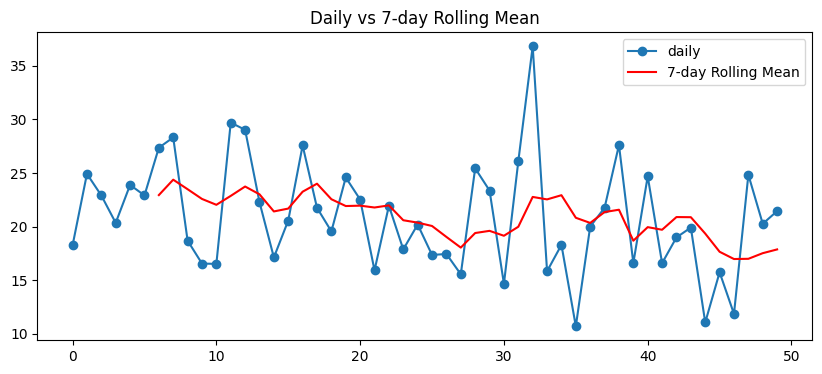

In [ ]:
# se.rolling(window=)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1. 50일간의 기온 데이터 생성
np.random.seed(32)
df = pd.DataFrame({"temp": np.random.normal(20,5, 50)})

# 2. 7일간격으로 기온 데이터을 묶어서/ (이동) 평균 구하여 그 결과을 컬럼으로 추가
df["7day_avg"]= df['temp'].rolling(window=7).mean()
print("\n", df)

# 선 그래프로 기온 변동성 시각화
plt.figure(figsize=(10,4))
plt.plot(df['temp'], label="daily", marker="o")
plt.plot(df['7day_avg'], label= "7-day Rolling Mean", color="red")
plt.title("Daily vs 7-day Rolling Mean")
plt.legend()
plt.show()

In [ ]:
# 정규화 작업 : min-max scaling
import pandas as pd
import numpy as np

# 10일치 기온과 강수량에 대한 테이블
data = {
    "temp": np.random.randint(-20,35,10),
    "rainfall": np.random.randint(0, 300, 10)}
df = pd.DataFrame(data)

# 정규화
def min_max_scale(series):
  result = (series - series.min()) / (series.max() - series.min())
  return result

df['temp_scaled'] = min_max_scale(df['temp'])
df['rainfall_scaled'] = min_max_scale(df['rainfall'])

print(df)

   temp  rainfall  temp_scaled  rainfall_scaled
0    20       125      1.00000         0.550661
1    -3         0      0.28125         0.000000
2    16       122      0.87500         0.537445
3   -12       227      0.00000         1.000000
4     5        82      0.53125         0.361233
5   -11       194      0.03125         0.854626
6    -2       136      0.31250         0.599119
7    -3       187      0.28125         0.823789
8    11        78      0.71875         0.343612
9    -2       220      0.31250         0.969163


In [ ]:
# se.map()
import pandas as pd

# DataFrame
df = pd.DataFrame({'gender_code':[0, 1,1,0]})

# Rule
def gender_map(x):
  if x == 0:
    return "F"
  else:
    return "M"
gender_map={0:"F", 1:"M"}
# 0-> F, 1 -> M mapping
df['gender_name']= df['gender_code'].map(gender_map)
print("\n", df)


    gender_code gender_name
0            0           F
1            1           M
2            1           M
3            0           F


day_eng
Fri      17.240025
Mon      17.335101
Sat      15.155772
Sun      17.365019
Thurs    19.500427
Tues     17.984317
Wed      18.704073
Name: temp, dtype: float64

 day_eng
Mon      17.335101
Tues     17.984317
Wed      18.704073
Thurs    19.500427
Fri      17.240025
Sat      15.155772
Sun      17.365019
Name: temp, dtype: float64


/tmp/ipykernel_3175/573335097.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='day_eng', y='temp', order=ordered_days, palette='Set3')


<Axes: ylabel='day_eng'>

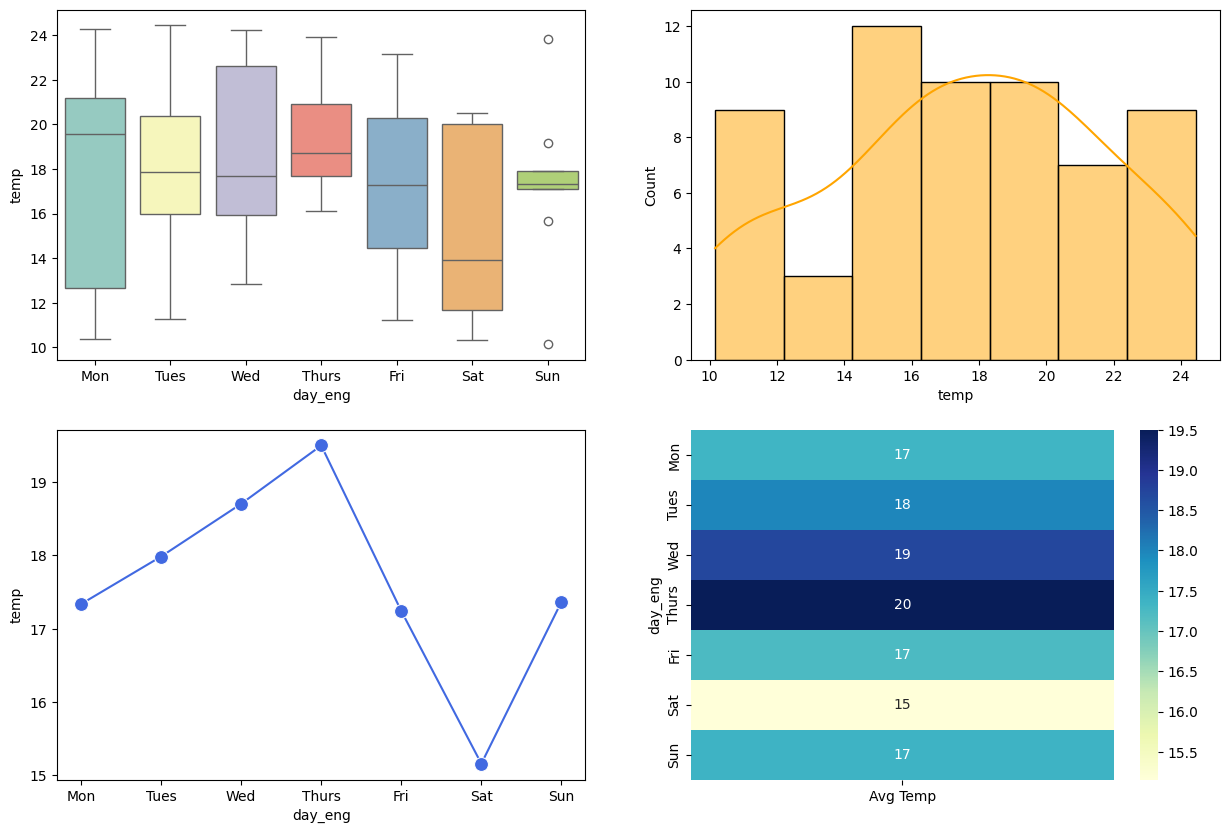

In [ ]:
# map(), df.index.dayofweek, df.index.day, df.reindex()
# sns.boxplot(), sns.lineplot(), sns.histplot(), sns.heatmap()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # 중간고사 범위에서 제외
# 1. 60일치 날짜 기온 데이터 생성
dates = pd.date_range(start="2026-03-01", periods=60)
df = pd.DataFrame({"temp": np.random.uniform(10, 25, 60)}, index = dates)
df['day_num'] = df.index.dayofweek #요일 숫자 (0~6)
df['month'] = df.index.month #월
# print("\n", df.head(50))

# 2.  숫자 요일 -> 영어명으로 전환 규칙
day_names = {0:'Mon', 1:'Tues', 2:'Wed', 3:'Thurs', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_eng'] = df.index.dayofweek.map(day_names)
# print("\n", df)
# 3. 데이터 가공- 요일별 /평균 기온 집계/ 및 재정렬
ordered_days = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
weekly_temp_mean = df.groupby('day_eng')['temp'].mean()
print(weekly_temp_mean )
weekly_temp_mean = weekly_temp_mean.reindex(ordered_days)
print("\n", weekly_temp_mean)

# 4. 종합시각화
plt.figure(figsize=(15, 10))
# [1] Boxplot: 요일별 기온 편차 (순서 정렬 추가)
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='day_eng', y='temp', order=ordered_days, palette='Set3')
# [2] Histplot: 기온 분포
plt.subplot(2, 2, 2)
sns.histplot(df['temp'], kde=True, color='orange')
# [3] Lineplot: 요일별 평균 기온 추이
plt.subplot(2, 2, 3)
sns.lineplot(data=weekly_temp_mean, marker='o', markersize=10, color='royalblue')
# [4] Heatmap: 요일별 평균 기온 (2차원 변환 적용)
plt.subplot(2, 2, 4)
heatmap_data = weekly_temp_mean.to_frame(name='Avg Temp') # seres->dataframe
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.tight_layout()
plt.show()